In [1]:
from control import SolveBVP
from model import Model
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# global variables
PARAMS = {
    "γ": 0.1,
    "ζ": 0.15,
    "η": 1,
    "α": 1e-5,    # guess without seasonal component
    "β": 0.0135,   # guess without seasonal component
    "u1": 0.1     # 150$ / timestep allows for new builds and maintenance
}

INITIAL_X = [475, 25, 0]
INITIAL_LAM = np.ones(3)

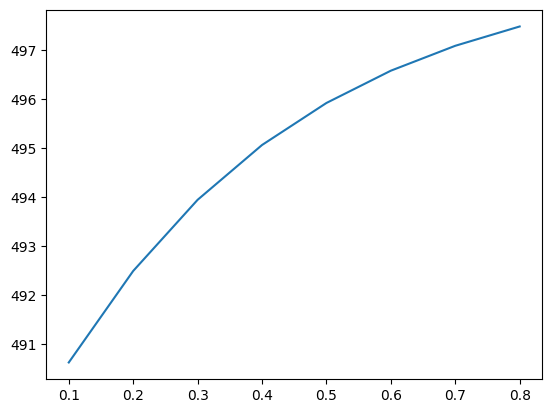

In [3]:
# want to plot u1 values against final surviving population
u1_vals = np.arange(.1, .9, .1)
surviving = []

# initialize model and iterate through different u1 values
for u_val in u1_vals:
    PARAMS["u1"] = u_val   # update param dictionary
    model = Model(seasonal=False, no_dead=True, const_u1=u_val)

    # use solve_bvp to solve the system
    bvp_solver = SolveBVP(
        const_params=PARAMS, 
        f=model.sy_f, tf=88, 
        initial_vals_x=INITIAL_X, 
        initial_vals_lam=INITIAL_LAM, 
        u1_const=u_val)
    sol = bvp_solver.solve()

    # store
    surviving.append(sol.y[0][-1] + sol.y[1][-1] + sol.y[2][-1])

# plot u1 against surviving
plt.plot(u1_vals, np.array(surviving))


#### Plot state solution and control solution for $u1 = 0.1$

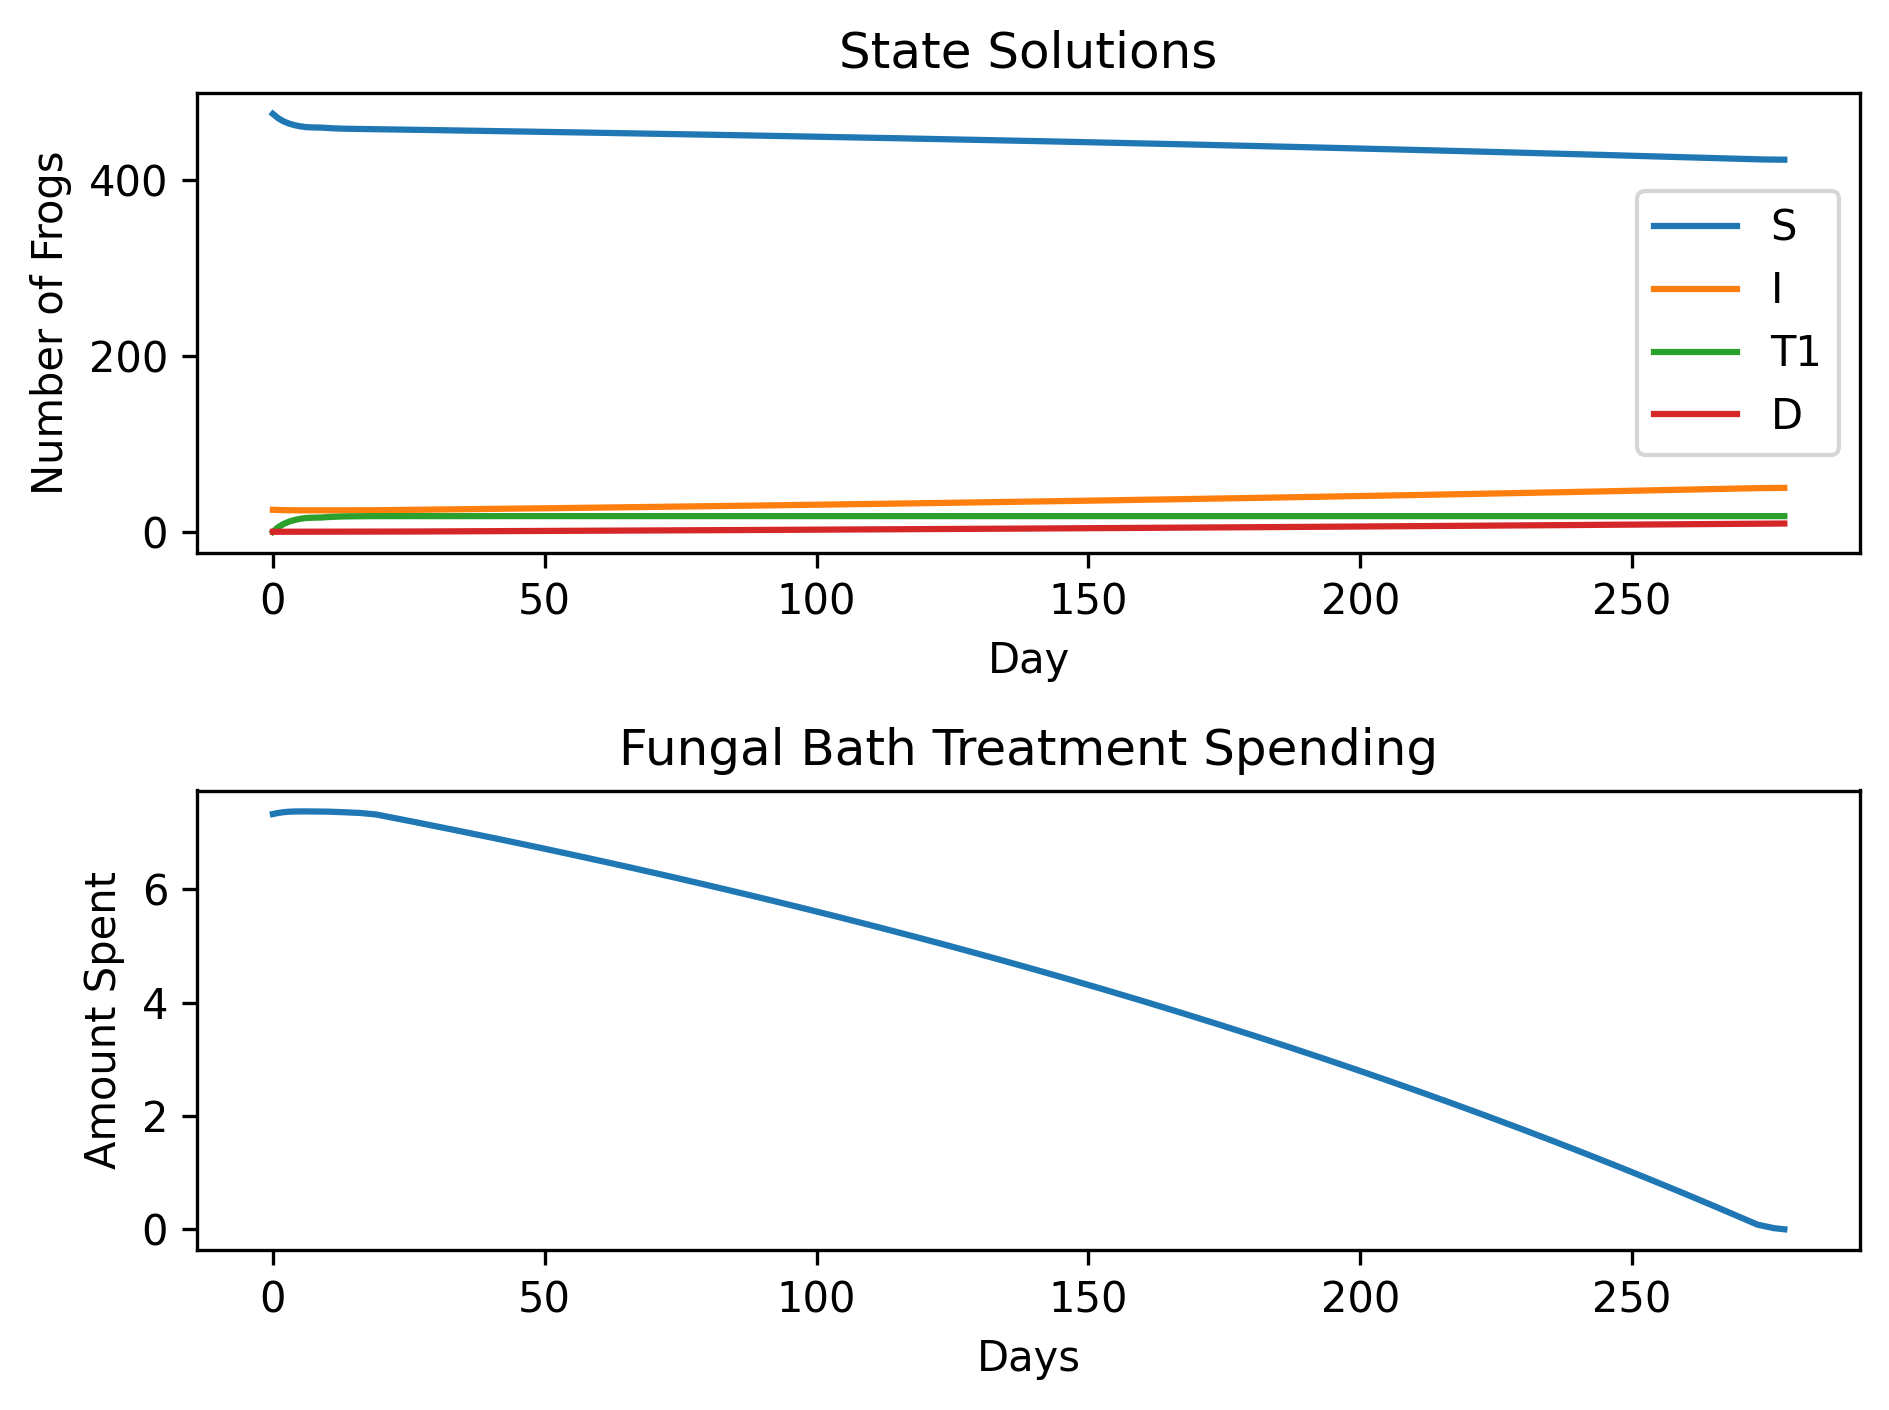

In [5]:
# initialize function and solver
PARAMS["u1"] = 0.1
model = Model(seasonal=False, no_dead=True, const_u1=0.1)
solver = SolveBVP(const_params=PARAMS, f=model.sy_f, tf=88, initial_vals_x=INITIAL_X, initial_vals_lam=INITIAL_LAM, no_dead=True, u1_const=0.1)
sol = solver.solve()

# plot solutions
plt.figure(dpi=300)
plt.subplot(211)
solver.plot_states()

plt.subplot(212)
solver.plot_u()

plt.tight_layout()
plt.show()